In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load data
df = pd.read_csv('House Price.csv')

In [2]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200
5,-122.25,37.85,52,919,213.0,413,193,4.0368,NEAR BAY,269700
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,NEAR BAY,299200
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,NEAR BAY,241400
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,NEAR BAY,226700
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,NEAR BAY,261100


In [3]:
df.dtypes

longitude             float64
latitude              float64
housing_median_age      int64
total_rooms             int64
total_bedrooms        float64
population              int64
households              int64
median_income         float64
ocean_proximity           str
median_house_value      int64
dtype: object

In [4]:
###Converting incorrect data types
#Change total_bedrooms from float64 to int64
df['total_bedrooms'] = df['total_bedrooms'].astype('Int64')
#Change ocean_proximity from str to category
df['ocean_proximity'] = df['ocean_proximity'].astype('category')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  int64   
 3   total_rooms         20640 non-null  int64   
 4   total_bedrooms      20433 non-null  Int64   
 5   population          20640 non-null  int64   
 6   households          20640 non-null  int64   
 7   median_income       20640 non-null  float64 
 8   ocean_proximity     20640 non-null  category
 9   median_house_value  20640 non-null  int64   
dtypes: Int64(1), category(1), float64(3), int64(5)
memory usage: 1.5 MB
None


In [5]:
###Detecting missing value
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [6]:
###Handleing the missing data
#In the total_rooms and population columns there is a wide range that suggest there could be a skewe
#For the listed reson I'll use Median Imputation to handle the outliers
df_imputed_median = df.copy()

In [7]:
# Calculate median
median_val = df['total_bedrooms'].median()

# Fix NaNs (No 'inplace=True' to avoid warnings)
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_val)

# Convert to float64 (Required for most ML models)
df['total_bedrooms'] = df['total_bedrooms'].astype('float64')

In [8]:
print(df_imputed_median.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


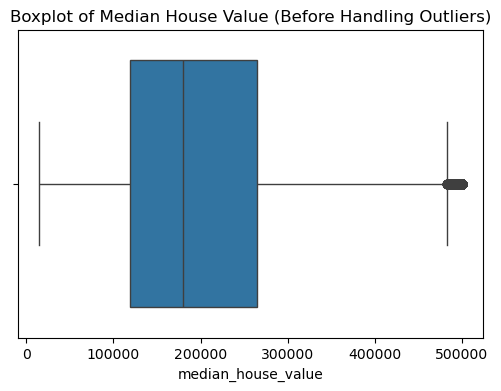

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['median_house_value'])
plt.title("Boxplot of Median House Value (Before Handling Outliers)")
plt.show()

In [10]:
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['median_house_value'] < lower) | (df['median_house_value'] > upper)]
outliers.head(15)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
89,-122.27,37.80,52,249,78.0,396,85,1.2434,NEAR BAY,500001
140,-122.18,37.81,30,292,38.0,126,52,6.3624,NEAR BAY,483300
459,-122.25,37.87,52,609,236.0,1349,250,1.1696,NEAR BAY,500001
489,-122.25,37.86,48,2153,517.0,1656,459,3.0417,NEAR BAY,489600
493,-122.24,37.86,52,1668,225.0,517,214,7.8521,NEAR BAY,500001
494,-122.24,37.85,52,3726,474.0,1366,496,9.3959,NEAR BAY,500001
509,-122.23,37.83,52,2990,379.0,947,361,7.8772,NEAR BAY,500001
510,-122.22,37.82,39,2492,310.0,808,315,11.8603,NEAR BAY,500001
511,-122.22,37.82,42,2991,335.0,1018,335,13.4990,NEAR BAY,500001
512,-122.23,37.82,52,3242,366.0,1001,352,12.2138,NEAR BAY,500001


In [16]:
df_no_outliers = df[(df['median_house_value'] >= lower) & (df['median_house_value'] <= upper)]
print("Original shape: ", df.shape)
print("After removing outliers: ", df_no_outliers.shape)

Original shape:  (20640, 10)
After removing outliers:  (19569, 10)


In [17]:
lower_cap = df['total_rooms'].quantile(0.05)
upper_cap = df['total_rooms'].quantile(0.95)

df_capped = df.copy()
df_capped['total_rooms'] = df_capped['total_rooms'].clip(lower_cap, upper_cap)

In [18]:
df[['total_rooms', 'total_bedrooms']].head()

,total_rooms,total_bedrooms
0,880,129.0
1,7099,1106.0
2,1467,190.0
3,1274,235.0
4,1627,280.0


In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df_scaled = df[['total_rooms', 'total_bedrooms']].copy()

df_scaled[['total_rooms', 'total_bedrooms']] = scaler_minmax.fit_transform(df_scaled)

df_scaled.head()

,total_rooms,total_bedrooms
0,0.022331,0.019863
1,0.180503,0.171477
2,0.037260,0.029330
3,0.032352,0.036313
4,0.041330,0.043296


In [20]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
df_standardized = df[['total_rooms', 'total_bedrooms']].copy()

df_standardized[['total_rooms', 'total_bedrooms']] = scaler_standard.fit_transform(df_standardized)

df_standardized.head()

,total_rooms,total_bedrooms
0,-0.804819,-0.972476
1,2.045890,1.357143
2,-0.535746,-0.827024
3,-0.624215,-0.719723
4,-0.462404,-0.612423


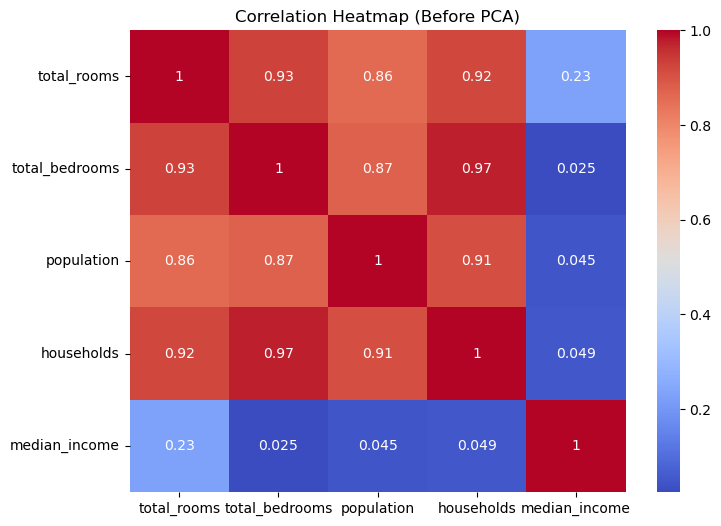

In [13]:
numerical_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
scaler = StandardScaler()
df_standardized = df_no_outliers[numerical_cols].copy()
df_standardized[numerical_cols] = scaler.fit_transform(df_standardized[numerical_cols])
plt.figure(figsize=(8, 6))
sns.heatmap(df_standardized[numerical_cols].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Before PCA)")
plt.show()

In [14]:
from sklearn.decomposition import PCA
X = df_standardized[['total_rooms', 'total_bedrooms']]

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.96544949 0.03455051]


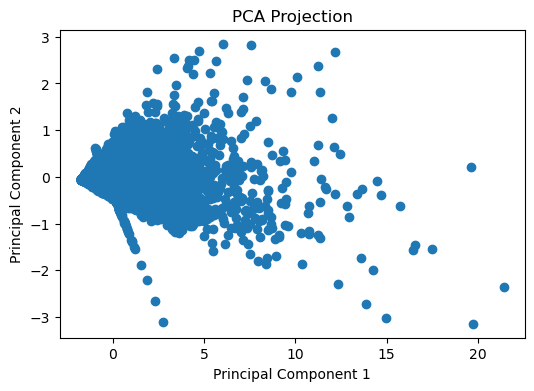

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()